Dataset Link: https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption

In [1]:
!pip install prophet --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats

In [3]:
df = pd.read_csv('powerconsumption.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.sort_values('Datetime', inplace=True)
df.set_index('Datetime', inplace=True)

target = 'PowerConsumption_Zone1'

df.head(3)

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Datetime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373


In [4]:
# Preprocessing Techniques
df[target] = df[target].interpolate(method='linear').ffill() # Missing values
df['MA_6'] = df[target].rolling(window=6).mean() # Smoothing (1 hour window)
df['Log_Target'] = np.log1p(df[target]) # Transformation
df['Diff1'] = df[target].diff().fillna(0) # Stationarity

In [5]:
# Outlier Treatment (Z-Score)
z_scores = np.abs(stats.zscore(df[target]))
df.loc[z_scores > 3, target] = df[target].median()

In [6]:
# Scaling
scaler = MinMaxScaler()
df['Scaled_Target'] = scaler.fit_transform(df[[target]])

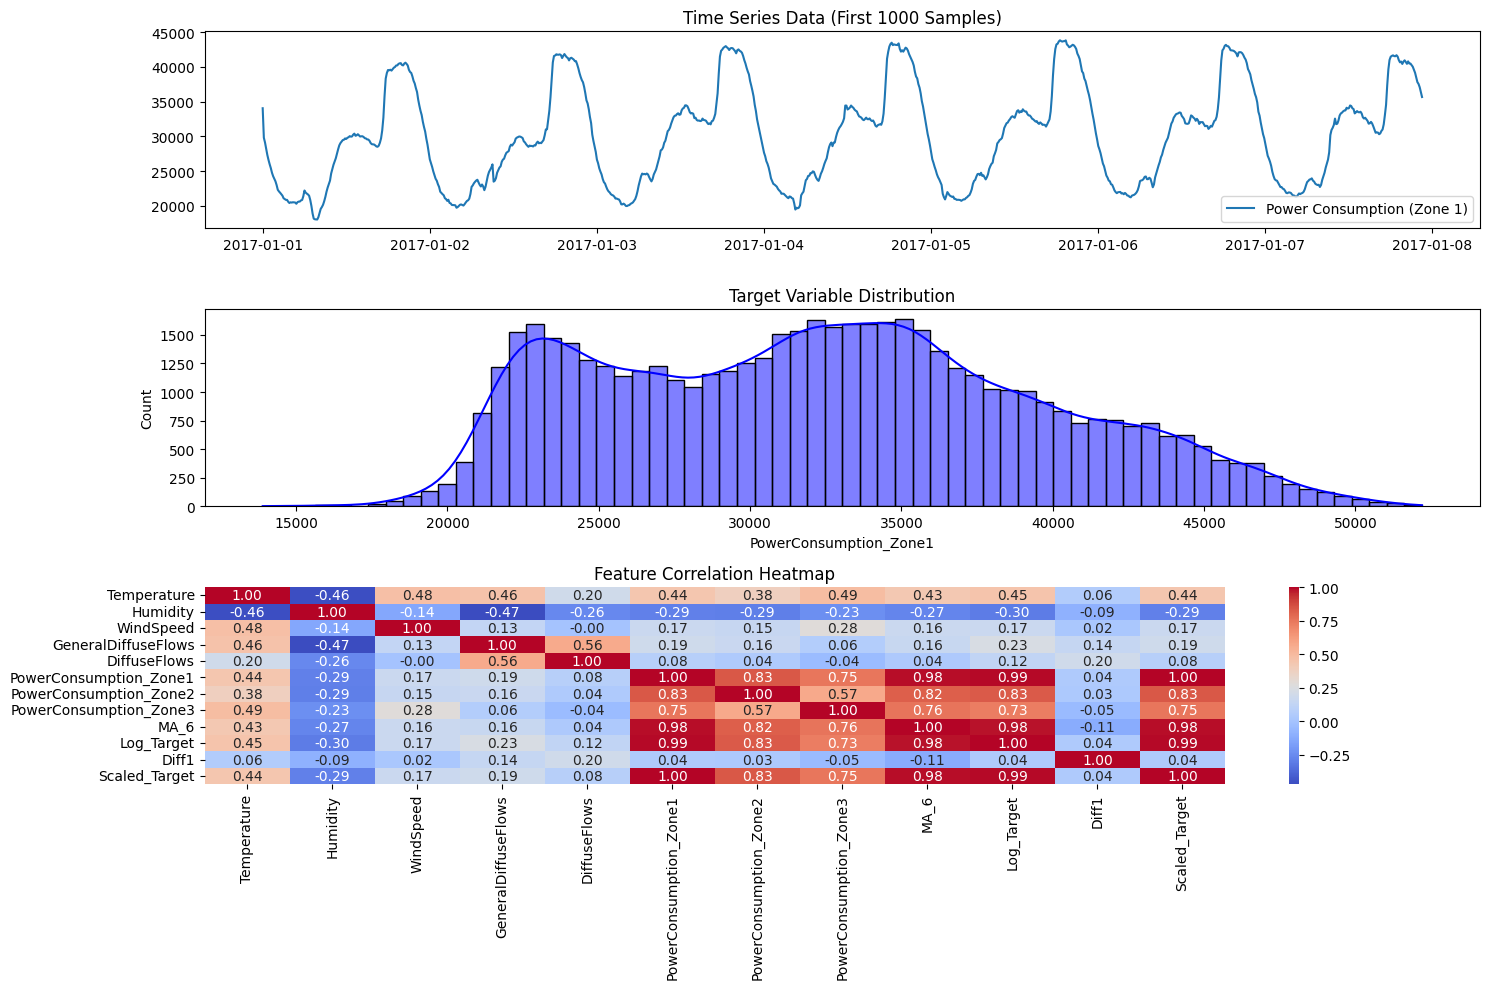

In [7]:
plt.figure(figsize=(15, 10))

# Time Series Plot
plt.subplot(3, 1, 1)
plt.plot(df.index[:1000], df[target][:1000], label='Power Consumption (Zone 1)')
plt.title('Time Series Data (First 1000 Samples)')
plt.legend()

# Distribution Plot
plt.subplot(3, 1, 2)
sns.histplot(df[target], kde=True, color='blue')
plt.title('Target Variable Distribution')

# Correlation Heatmap
plt.subplot(3, 1, 3)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [8]:
# 3. DATA PREPARATION FOR MODELS
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

WINDOW_SIZE = 24 # 24 * 10 mins = 4 hours of context
X_data, y_data = create_sequences(df['Scaled_Target'].values, WINDOW_SIZE)

# Train/Test Split (80/20)
split = int(len(X_data) * 0.8)
X_train, X_test = X_data[:split], X_data[split:]
y_train, y_test = y_data[:split], y_data[split:]

Epoch: 0/5 	Loss: 2.956016429583542
Epoch: 1/5 	Loss: 0.42522472629207186
Epoch: 2/5 	Loss: 0.2603575553803239
Epoch: 3/5 	Loss: 0.17497815928072669
Epoch: 4/5 	Loss: 0.13756223580276128


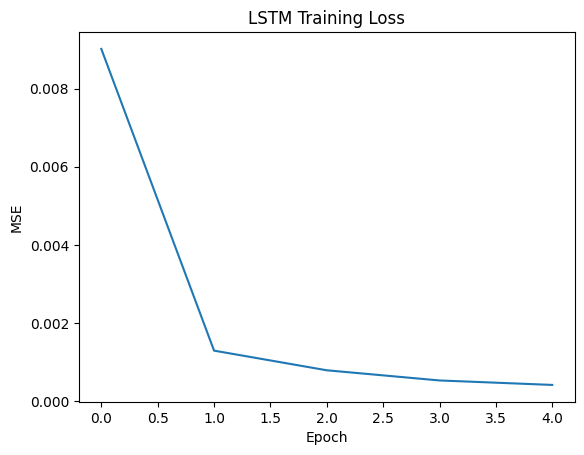

In [9]:
# TimeSeriesDataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # Shape: (samples, seq_len, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # Shape: (samples, 1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create DataLoader for batching
train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=128, shuffle=False)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=128, shuffle=False)

# LSTM Model class
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)  # LSTM outputs (batch_size, seq_len, hidden_size)
        return self.fc(out[:, -1, :])  # Take the last output for prediction

# Define device, model, loss function, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lstm = LSTMModel().to(device)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Training Loop
epochs = 5
train_losses = []

for epoch in range(epochs):
    model_lstm.train()
    total_loss = 0
    for b_x, b_y in train_loader:
        b_x, b_y = b_x.to(device), b_y.to(device)
        
        # Ensure the input is of shape (batch_size, seq_len, input_size)
        b_x = b_x.view(b_x.size(0), -1, 1)  # This assumes a single feature (input_size=1)
        
        optimizer.zero_grad()
        output = model_lstm(b_x)
        loss = criterion(output, b_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    train_losses.append(total_loss / len(train_loader))

    print(f"Epoch: {epoch}/{epochs} \tLoss: {total_loss}")

# Plot Training Loss
plt.figure()
plt.plot(train_losses)
plt.title('LSTM Training Loss')
plt.xlabel('Epoch') 

plt.ylabel('MSE')
plt.show()

model_lstm.eval()
lstm_preds = []
with torch.no_grad():
    for b_x, _ in test_loader:
        lstm_preds.append(model_lstm(b_x.to(device)).cpu().numpy())
lstm_preds = scaler.inverse_transform(np.concatenate(lstm_preds))

In [10]:
# 5. MODEL 2: RANDOM FOREST
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = scaler.inverse_transform(rf_model.predict(X_test).reshape(-1, 1))

In [11]:
# 6. MODEL 3: ARIMA
# Fitting on a subset for speed (last 5000 rows of training data)
history = list(df[target].iloc[split-5000:split])
arima_model = ARIMA(history, order=(2, 1, 2))
arima_fit = arima_model.fit()

arima_preds = arima_fit.forecast(steps=len(y_test))

In [12]:
from prophet import Prophet 

prophet_df = df[['Scaled_Target']].reset_index()
prophet_df.columns = ['ds', 'y']

# Align with windowed data
prophet_df = prophet_df.iloc[WINDOW_SIZE:].reset_index(drop=True)

# Split (aligned with y_test)
split_idx = split

train_df = prophet_df.iloc[:split_idx]
test_df = prophet_df.iloc[split_idx:]

# Add aligned regressors
features = ['Temperature', 'Humidity', 'WindSpeed']

for col in features:
    aligned_values = df[col].iloc[WINDOW_SIZE:].values
    train_df[col] = aligned_values[:split_idx]
    test_df[col] = aligned_values[split_idx:]

# Model
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.3  
)

model.add_seasonality(
    name='intraday',
    period=1,
    fourier_order=15
)

for col in features:
    model.add_regressor(col)
 
model.fit(train_df)

# Build future  
future = test_df.copy()
future = future[['ds'] + features]

# Predict
forecast = model.predict(future)

# Extract predictions
prophet_preds = forecast['yhat'].values

# Match shape + inverse scale
prophet_preds = prophet_preds.reshape(-1, 1)
prophet_preds = scaler.inverse_transform(prophet_preds)

/home/larson/College Stuff/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
11:32:05 - cmdstanpy - INFO - Chain [1] start processing
11:33:12 - cmdstanpy - INFO - Chain [1] done processing


           Model          MAE         RMSE        R2
0           LSTM   423.149138   608.732153  0.990258
1  Random Forest   269.736560   397.634990  0.995843
2          ARIMA  5938.802583  7315.414916 -0.406909
3        Prophet  3469.791073  3947.946069  0.590239


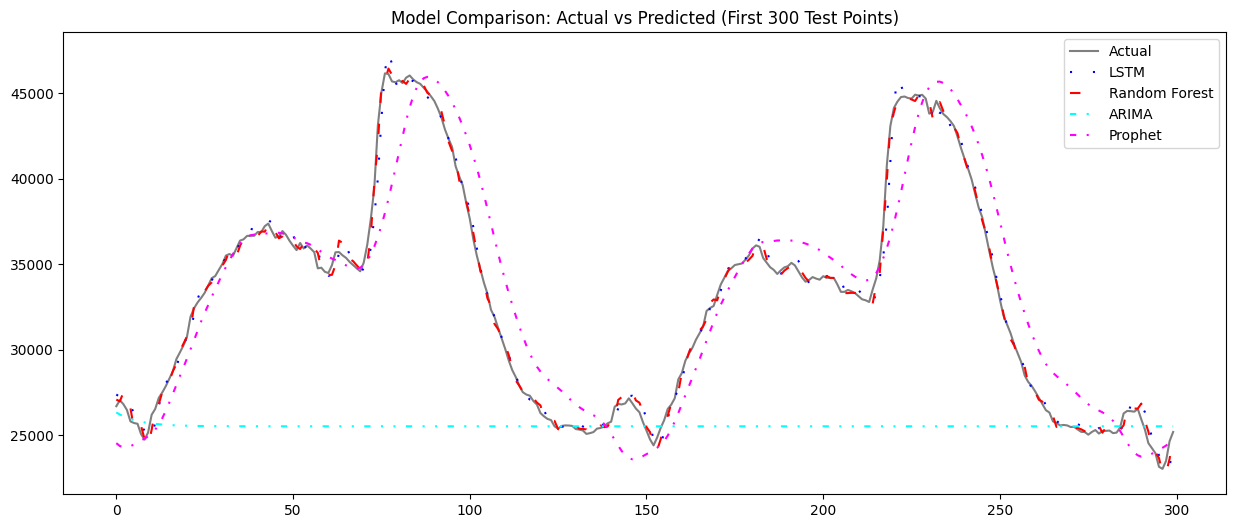

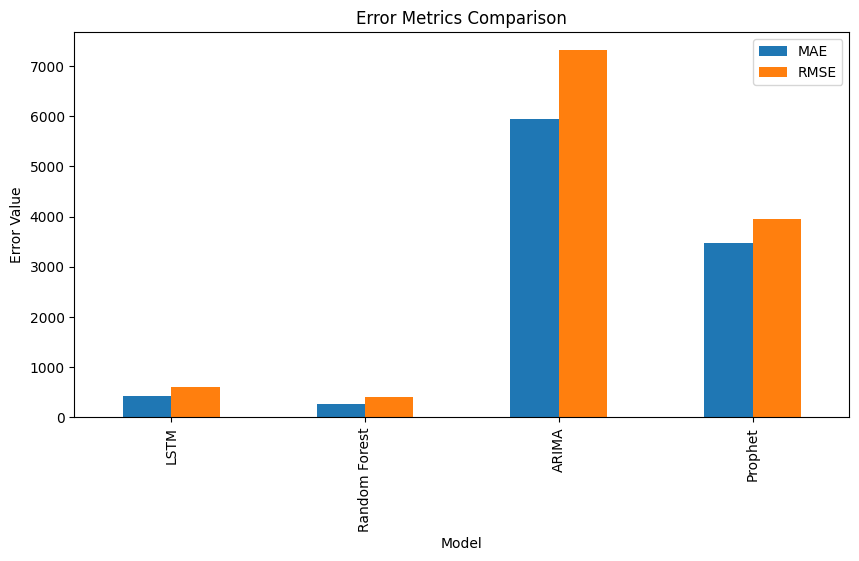

In [13]:
# 7. EVALUATION AND VISUALIZATION
def get_metrics(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Predictions
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrics Calculation
m1 = get_metrics(y_test_actual, lstm_preds, 'LSTM')
m2 = get_metrics(y_test_actual, rf_preds, 'Random Forest')
m3 = get_metrics(y_test_actual, arima_preds, 'ARIMA')
m4 = get_metrics(y_test_actual, prophet_preds, 'Prophet')

perf_df = pd.DataFrame([m1, m2, m3, m4])
print(perf_df)

# Performance Visualizations
plt.figure(figsize=(15, 6))
plt.plot(y_test_actual[:300], label='Actual', color='black', alpha=0.5)
plt.plot(lstm_preds[:300], label='LSTM', linestyle=(0, (1, 10)), color='blue')
plt.plot(rf_preds[:300], label='Random Forest', linestyle=(0, (5, 10)), color="red")
plt.plot(arima_preds[:300], label='ARIMA', linestyle=(0, (3, 5, 1, 5, 1, 5)), color='cyan')
plt.plot(prophet_preds[:300], label='Prophet', linestyle=(0, (3, 5, 1, 5)), color='magenta')
plt.title('Model Comparison: Actual vs Predicted (First 300 Test Points)')
plt.legend()
plt.show()

# Bar Chart of Metrics
perf_df.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 5))
plt.title('Error Metrics Comparison')
plt.ylabel('Error Value')
plt.show()